# **Hopfield's Sunrise**
---
A neuroscientific model regarding pattern recognition and classification of Sun and Clouds, using a Hopfield Network and a single-layer perceptron.


#Introduction

The original Hopfield network is a single layer, fully connected recurrent neural network, initially proposed in 1982 by John Hopfield. Due to it's ability to recover stored patterns, it serves as a model for associative memory, i.e. *content addressable memory* (CAM). Therefore, it can be used to aid our understanding of how memory systems like the hippocampus work. After all, the CA3 hippocampal region also forms a recurrent network, which is thougth to store memories via plasticity of the synapses (i.e. changing the synaptic weights). Similarly, the Hopfield network stores patterns though changes in the connection strength between its units. This allows the network to reconstruct a memory from a partial pattern. By evolving towards the local lowest energy states, it recovers patterns that are stored as *fixed point attractors*.

However, the Hopfield network is not without drawbacks. Amongst others, it's weaknesses concern it's *low memory capacity* and the emergence of *spurious state*.

This project will aim to visualize and explain the process of storage and retrieval of patterns in the Hopfield network, using patterns of sun and clouds. Furthermore, the performance of the network will be assessed by classifying whether the retrieved pattern falls within the intended category, using a single-layer perceptron. Additionaly, a mathematical foundation will be provided regarding the notion of Hopfield energy, capacitiy of the network and the emergence of spurious states.

# Initialization

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

np.random.seed(1)

#Hopfield Network

The evolution of the Hopfield network will be calculated using discretized time steps. Therefore, the state of the network at time $t+1$ will be a function of the state at the previous time step:

$${a_i = sgn(}\sum_{j\neq i}{w_{ij}a_j+b_i})$$

Where:


*   $sgn = \left\{\begin{array}{ll} +1 & \mbox {if }\sum_{j\neq i}{w_{ij}a_j+b_i}\geq 0, \\
 -1 & \mbox {otherwise.}\end{array}\right.$
  * Each neuron uses the perceptron algorithm to produce an output of either $-1$ or $1$
*   $w_{ij} = w_{ji}$
  * The weight from neuron $i$ to neuron $j$ is equal to the weight from neuron $j$ to neuron $i$ (symmetric connections)
*$j\neq i$ because there are no recurrent self-connections (diagonal weights are set to 0)
* $a_i$ is the state (or activity) of neuron $i$
* $b_i$ is the threshold (e.g. bias)
  * This project will assume $b_i = 0$

In other words, at every timestep neuron $i$ receives a local "field" ($\sum_{j\neq i}{w_{ij}a_j+b_i}$). If the sign of that field matches its own sign, the neuron will remain in its current state. However, if the sign of the field is opposite to its own sign, the state of the neuron will "flip" to match the sign of the local field:

$$a_i \rightarrow -a_i \text{ if } a_i(\sum_{j\neq i}{w_{ij}a_j+b_i})< 0$$

This line of reasoning originates from the Spin-Glass Theory (Ising model) in physics.  













##Patterns of the datasets

The first step is to create a dataset. Here, the dataset shall consist of twenty patterns, made from arrays containing {$-1,1$}. These arrays give rise to images of sun and clouds, ten of each weather state.

###Sunny patterns

In [15]:
# Defining the patterns for the sunny states
# Note: Initially these arrays consist of values in {0,1}, later the zeros will be converted into -1's
sun1 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

sun2 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

sun3 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                 [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
                 [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

sun4 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0],
                 [0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0],
                 [0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0],
                 [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
                 [0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0],
                 [0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0],
                 [0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

sun5 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0],
                 [0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0],
                 [0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1],
                 [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1],
                 [1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
                 [0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0],
                 [0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]])

sun6 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0],
                 [1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1],
                 [0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

sun7 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0],
                 [0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0],
                 [1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1],
                 [0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                 [0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

sun8 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0],
                 [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
                 [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0],
                 [0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0],
                 [0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
                 [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0],
                 [0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

sun9 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0],
                 [0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0],
                 [0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                 [0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0],
                 [0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

sun10 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
                 [0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0],
                 [0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0],
                 [0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                 [0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0],
                 [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0],
                 [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0],
                 [0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 0],
                 [0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0],
                 [0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

# Combining the matrices of the sunny patterns into a list
sunny_patterns = [sun1, sun2, sun3, sun4, sun5, sun6, sun7, sun8, sun9, sun10]

for pattern in sunny_patterns:        # using a for loop to loop through all the sunny patterns in the list
  pattern[pattern==0] = -1            # replacing every 0 in the matrix of the pattern by -1, such that it corresponds to the assumption of the Hopfield network (activity of a unit is either -1 of +1)

# Flattening the patterns, such that that can be used in further analysis
s1_flat = sun1.flatten(); s2_flat = sun2.flatten(); s3_flat = sun3.flatten(); s4_flat = sun4.flatten(); s5_flat = sun5.flatten();
s6_flat = sun6.flatten(); s7_flat = sun7.flatten(); s8_flat = sun8.flatten(); s9_flat = sun9.flatten(); s10_flat = sun10.flatten();

# Combining the flattened row vectors of the cloudy patterns into a list
sunny_patterns_flat = [s1_flat, s2_flat, s3_flat, s4_flat, s5_flat, s6_flat, s7_flat, s8_flat, s9_flat, s10_flat]

###Cloudy Patterns

In [16]:
# Defining the patterns for the cloudy states
cloud1 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0],
                   [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

cloud2 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0],
                   [0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0],
                   [0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                   [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

cloud3 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
                   [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

cloud4 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
                   [0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

cloud5 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
                   [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

cloud6 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0],
                   [0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

cloud7 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
                   [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

cloud8 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
                   [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

cloud9 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                   [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
                   [0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0],
                   [0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

cloud10 = np.array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0],
                   [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
                   [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
                   [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])


# Combining the matrices of the cloudy patterns into a list
cloudy_patterns = [cloud1, cloud2, cloud3, cloud4, cloud5, cloud6, cloud7, cloud8, cloud9, cloud10]

for pattern in cloudy_patterns:        # using a for loop to loop through all the sunny patterns in the list
  pattern[pattern==0] = -1             # replacing every 0 in the matrix of the pattern by -1, such that it corresponds to the assumption of the Hopfield network (activity of a unit is either -1 of +1)


# Flattening the patterns, such that that can be used in further analysis
cl1_flat = cloud1.flatten(); cl2_flat = cloud2.flatten(); cl3_flat = cloud3.flatten(); cl4_flat = cloud4.flatten(); cl5_flat = cloud5.flatten();
cl6_flat = cloud6.flatten(); cl7_flat = cloud7.flatten(); cl8_flat = cloud8.flatten(); cl9_flat = cloud9.flatten(); cl10_flat = cloud10.flatten();

# Combining the flattened row vectors of the cloudy patterns into a list
cloudy_patterns_flat = [cl1_flat, cl2_flat, cl3_flat, cl4_flat, cl5_flat, cl6_flat, cl7_flat, cl8_flat, cl9_flat, cl10_flat]


###Plotting the patterns

<ipython-input-17-b8ccfc9f271f>:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colour_map = plt.cm.get_cmap('gray')  # defining the colourmap


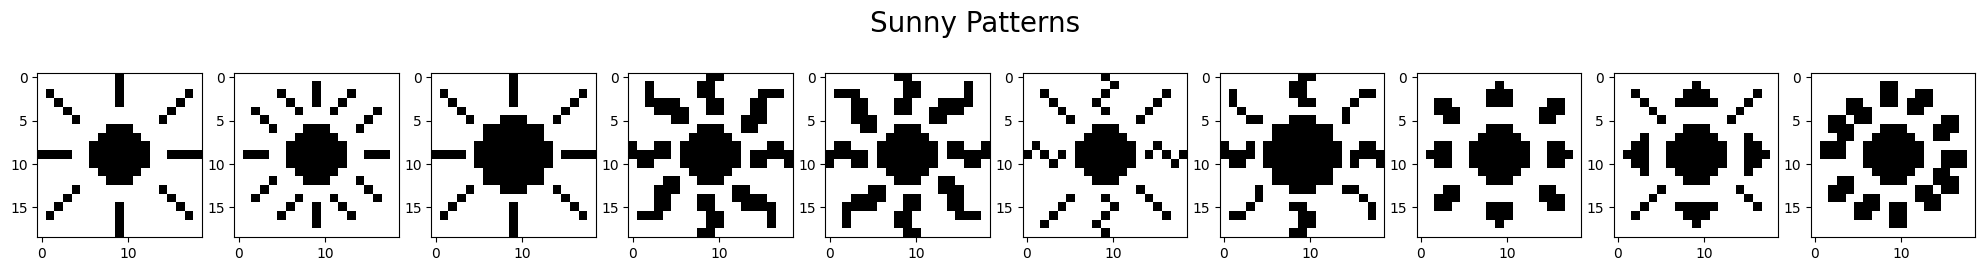

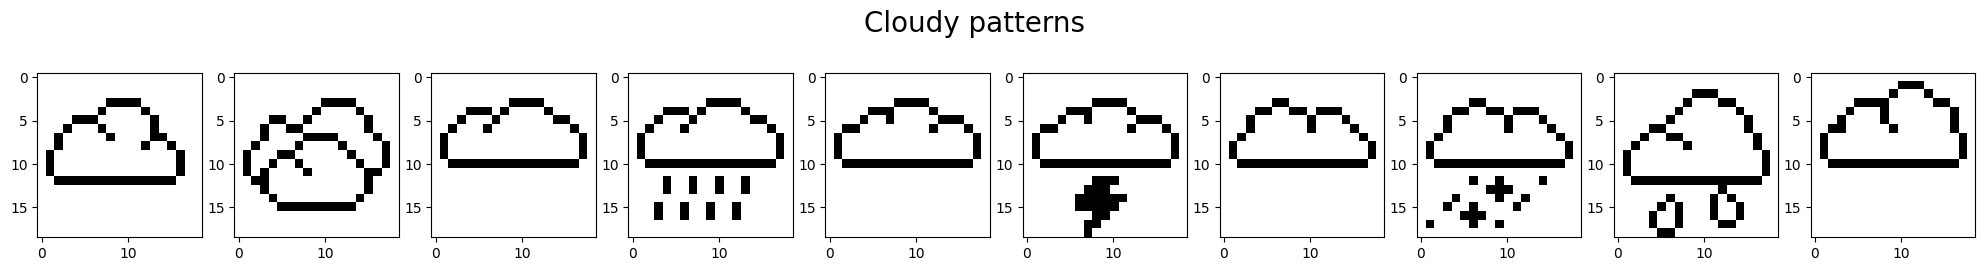

In [17]:
#Plotting the sunny patterns
colour_map = plt.cm.get_cmap('gray')  # defining the colourmap
reversed_map = colour_map.reversed()  # reversing the colours in the colourmap, such that -1 is represented by white, and +1 is represented by black
plt.figure(figsize=(25,3))            # setting the size of the total figure
plt.suptitle("Sunny Patterns", fontsize = 20)
index = 1                             # creating an integer called 'index', which will be used to create the subplots of the patterns

for pattern in sunny_patterns:        # using a for loop to loop through all the sunny patterns in the list
  plt.subplot(1,10,index)
  plt.imshow(pattern, cmap = reversed_map)
  index += 1


#Plotting the cloudy patterns
plt.figure(figsize=(25,3))           # setting the size of the total figure
plt.suptitle("Cloudy patterns", fontsize = 20)

index = 1                             # setting the index back to 1, which will be used to create the subplots of the patterns

for pattern in cloudy_patterns:        # using a for loop to loop through all the sunny patterns in the list
  plt.subplot(1,10,index)
  plt.imshow(pattern, cmap = reversed_map)
  index += 1

##Training the Hopfield network

The weights in the weight matrix determine which patterns are stored as fixed point attractors in the network. To generate this weight matrix, different learning rules can be applied. This project will assume the *Hebbian learning rule*, which is the first learning rule that was proposed for the Hopfield network.

* Storing a single pattern:
$w_{ij}=\xi_i \xi_j$
  * Where $\xi$ is a vector containing the states for the pattern that is to be stored
  * Thus, the total weights matrix equals the outer product of the pattern (that is to be stored) with itself
    * $\textbf{W} = \textbf{ξ}^T \textbf{ξ}$.


* Storing multiple patterns: $w_{ij}=\frac{1}{N} \sum_{k}{\xi_i^k \xi_j^k}$.
  * Where $k$ denotes the $k^{th}$ pattern and $N$ the number of stored patterns
  * The weight matrix is normalized through scaling by
$\frac{1}{N}$. Note that this doesn't affect the
pattern storage.
  * Likewise, this equation can also be written in the form of matrix multiplication
    * $\textbf{W} = \frac{1}{N} \sum_{k}{\textbf{ξ}_k^T \textbf{ξ}_k}$

Thus, the Hebbian learning rule states that two neurons that are active together (i.e. that have the same sign) form a positive (i.e. excitatory) connection between them. On the other hand, if the signs of the two neurons oppose each other, the connection becomes negative (i.e. inhibitory).

To ensure adequate storage of patterns, patterns should be both *stationary* and *stable*.

* Stationary: The pattern is stationary if it remains the same after initialisation.
  * $sgn(\sum_{j\neq i}{w_{ij}a_j})=a_i \text{ } \forall \text{ } i$
  * Hebbian learning implies stationarity for single pattern storage, where $a=\xi$
    * $sgn(\sum_{j\neq i}{w_{ij}a_j})=sgn(\sum_{j\neq i}{a_i a_j a_j})=sgn(\sum_{j\neq i}{a_i a_j^2})=sgn(\sum_{j\neq i}{a_i})=a_i$
* Stable: After perturbations to the system, it evolves back to the stored pattern
  * Through Hebbian learning of a single pattern, the energy value (see later segment on Hopfield energy) is the lowest for the stored pattern



### Convergence in one step

As stated by the equations of the Hopfield network; if the total input to the neuron $i$ (i.e. $\sum_{j\neq i}{w_{ij}a_j}$) has the same sign as the current state of the neuron, the neuron is said to be in the *correct state* given its input.

Using Hebbian learning, a statement can be derived that gives insight into the underlying conditions that determine the sign of the total input $I$, assuming a single stored pattern whose neuron activities are represented by $ξ$:
$$I_i=\sum_{j\neq i}{w_{ij}a_j}$$
$$ =\sum_{j\neq i}{\xi_i \xi_j a_j} $$
$$ =\xi_i(\sum_{j=correct}{\xi_j a_j}+\sum_{j=incorrect}{\xi_j a_j}) \text{ for} j \neq i$$
Given that $\xi_j a_j = 1$ if $a_j$ is in the correct state (i.e. the same state as the stored pattern, thus $\xi_j = a_j$) and $\xi_j a_j = -1$ if $a_j$ is in the incorrect state:
$$I_i=\xi_i(N_{correct}-N_{incorrect})$$

Thus, if the majority of the neurons $j$ that are connected to neuron $i$ are in the correct state (as given by the stored pattern), then the total input shall induce neuron $i$ to have the correct sign as well.

This means that if an initial pattern is given to the network, such that the majority of the neurons are in the correct state, then all of the neurons shall converge to the correct state after just one iteration.


###Creating the Weight Matrix

In [5]:
# Defining the list of patterns that will be used for the training procedure
# -> These patterns will function as the stored memories of the Hopfield network
# Different training sets are given as examples. However, note that every possible combination of patterns in the dataset could be used as training data.

#training_set = np.array((sunny_patterns_flat[0], cloudy_patterns_flat[2]))

# training_set = []
# for i in range(0, 10):
#   training_set.append(cloudy_patterns_flat[i])
#   training_set.append(sunny_patterns_flat[i])
# training_set = np.array(training_set)

#training_set = np.array((cloudy_patterns_flat[2], sunny_patterns_flat[2], cloudy_patterns_flat[6], sunny_patterns_flat[6], cloudy_patterns_flat[4], sunny_patterns_flat[4]))
#training_set = np.array((cloudy_patterns_flat[2], sunny_patterns_flat[2], cloudy_patterns_flat[4], sunny_patterns_flat[4]))
training_set = np.array((cloudy_patterns_flat[2], sunny_patterns_flat[3], cloudy_patterns_flat[4], sunny_patterns_flat[4], cloudy_patterns_flat[6], sunny_patterns_flat[5]))
#training_set = np.array((cloudy_patterns_flat[2], sunny_patterns_flat[3], cloudy_patterns_flat[4], sunny_patterns_flat[4], cloudy_patterns_flat[6], sunny_patterns_flat[6]))




# One-shot (Hebbian) learning to generate the weight matrix, using the training set
def weights_matrix(states):
  dim = states.shape[1]                   # get the dimensions of the pattern (number of nodes)
  W = np.zeros((dim,dim))                 # use the dimensions to generate an empty weight matrix
  for state in states:
    W_state = np.outer(state,state)       # outer product of the state of the pattern you want to store
    np.fill_diagonal(W_state, 0)          # remove recurrent self-connections
    W += W_state
  W = W / len(states)                     # normalize the weight matrix by dividing the values in the weight matrix by the amount of states (patterns) used to generate the matrix
  return W

W = weights_matrix(training_set)

####Plotting the weight matrix after training

Text(0.5, 1.0, 'Trained Weight Matrix')

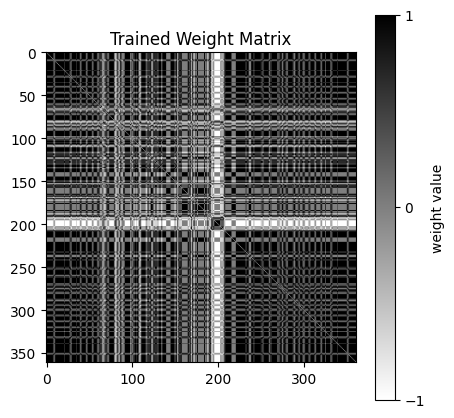

In [6]:
plt.figure(figsize = (5, 5))
plt.imshow(W, cmap = reversed_map)
plt.colorbar(ticks = [-1,0,1], label = 'weight value')
plt.title('Trained Weight Matrix')

##Testing the trained Hopfield network

After the Hopfield network has been trained via One-shot Hebbian learning, it's ability to retrieve the stored patterns can be assessed. The evolution of the input patterns (from the dataset) will be calculated using the equation introduced above, namely:
$${a_i = sgn(}\sum_{j\neq i}{w_{ij}a_j})$$
In the form of matrix multiplication:
$${\textbf{a}^T  = sgn(\textbf{Wa}^T)}$$

###Calculating the evolution of the patterns

In [7]:
# Calculate how the state evolves as a function of the matrix product between the weights matrix and the previous state of the network
timesteps = 10

def sign(state, threshold = 0):                   # The hopfield network has binary threshold neurons that operate through a sign function
                                                  # Meaning that the output equals 1 for positive inputs, and -1 for negative inputs
  state[state>=threshold] = 1
  state[state<threshold] = -1
  return state

def state_evolution(state, W):
  state_old = state.T
  state_evolution_list = []                       # Generate an empty list to hold how the state of the states during each timestep
  state_evolution_list.append(state_old)          # Append the initial state to the list
  for i in range(timesteps):
    state_new = W@state_old                       # Dot product (inner product) of the current state and the weights matrix gives the state at the next timestep
    a = sign(state_new)
    state_evolution_list.append(a)                # Append the state of the network after every iteration to the list
    state_old = state_new
  return state_evolution_list

In [8]:
# Calculating the evolution of the sunny states
state_evolution_s1 = state_evolution(sunny_patterns_flat[0], W)
state_evolution_s2 = state_evolution(sunny_patterns_flat[1], W)
state_evolution_s3 = state_evolution(sunny_patterns_flat[2], W)
state_evolution_s4 = state_evolution(sunny_patterns_flat[3], W)
state_evolution_s5 = state_evolution(sunny_patterns_flat[4], W)
state_evolution_s6 = state_evolution(sunny_patterns_flat[5], W)
state_evolution_s7 = state_evolution(sunny_patterns_flat[6], W)
state_evolution_s8 = state_evolution(sunny_patterns_flat[7], W)
state_evolution_s9 = state_evolution(sunny_patterns_flat[8], W)
state_evolution_s10 = state_evolution(sunny_patterns_flat[9], W)

# Calculating the evolution of the cloudy states
state_evolution_cl1 = state_evolution(cloudy_patterns_flat[0], W)
state_evolution_cl2 = state_evolution(cloudy_patterns_flat[1], W)
state_evolution_cl3 = state_evolution(cloudy_patterns_flat[2], W)
state_evolution_cl4 = state_evolution(cloudy_patterns_flat[3], W)
state_evolution_cl5 = state_evolution(cloudy_patterns_flat[4], W)
state_evolution_cl6 = state_evolution(cloudy_patterns_flat[5], W)
state_evolution_cl7 = state_evolution(cloudy_patterns_flat[6], W)
state_evolution_cl8 = state_evolution(cloudy_patterns_flat[7], W)
state_evolution_cl9 = state_evolution(cloudy_patterns_flat[8], W)
state_evolution_cl10 = state_evolution(cloudy_patterns_flat[9], W)

###Visualisation of the timeseries of a single pattern

Thus, as defined in the code, the twenty images from the dataset are fed into the Hopfield network for ten iterations, using the weight matrix to make the patterns converge into a stable state. The plot below shows how a random pattern, and the fourth sunny pattern evolve through those iterations.

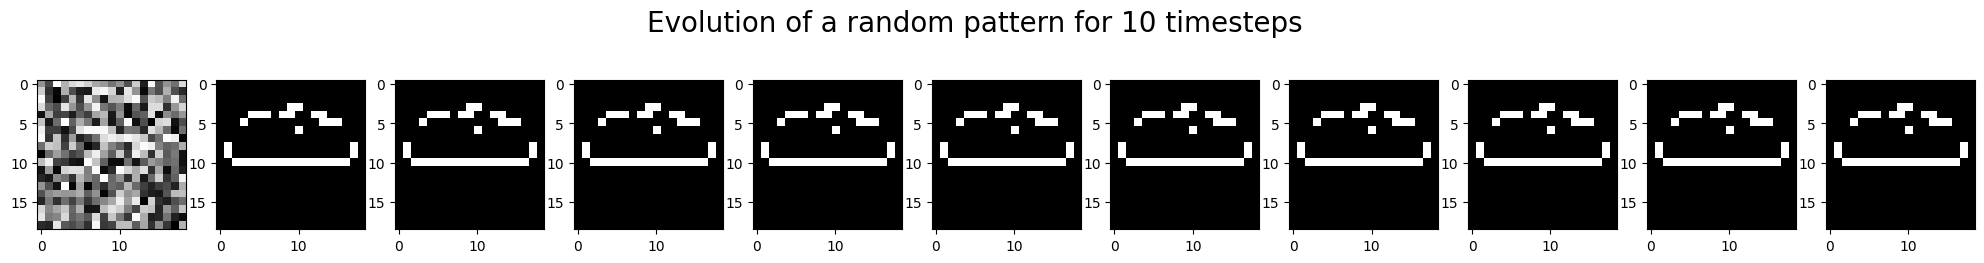

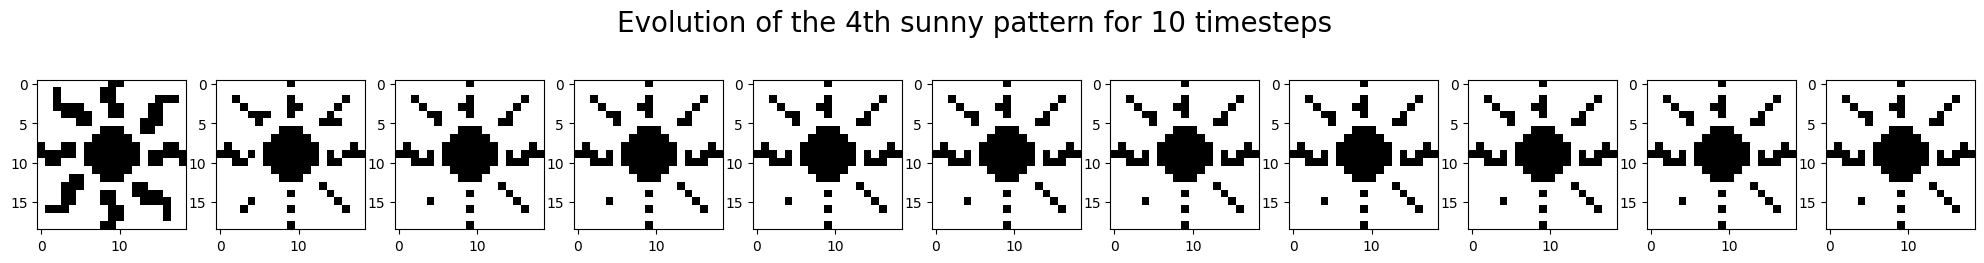

In [9]:
plt.figure(figsize=(25,3))
plt.suptitle('Evolution of a random pattern for 10 timesteps', fontsize = 20)

random_state = np.random.rand(1,19*19);
random_state_evolution = state_evolution(random_state, W*.1)

for  ii in range(0,timesteps+1):
    plt.subplot(1, timesteps+1, ii+1)
    plt.imshow(random_state_evolution[ii].reshape((19,19)), cmap = reversed_map)


plt.figure(figsize=(25,3))
plt.suptitle('Evolution of the 4th sunny pattern for 10 timesteps', fontsize = 20)
for  ii in range(0,timesteps+1):
  plt.subplot(1, timesteps+1, ii+1)
  plt.imshow(state_evolution_s4[ii].reshape((19,19)), cmap = reversed_map)

###Final states of the patterns

The Hopfield network is supposed to work as a model for content-addressable memory. Upon giving it an initial configuration, the pattern always evolves to a fixed point attractor. However, as will be explained later, those fixed point attractors don't always resemble the patterns that were stored initially during training. The plot below visualises the final states of all twenty patterns after 10 iterations through the network. The order of the sequence corresponds to that of the initial dataset. In other words, the first row shows the final states of the sunny patterns, whereas the second row shows the final states of the cloudy patterns.

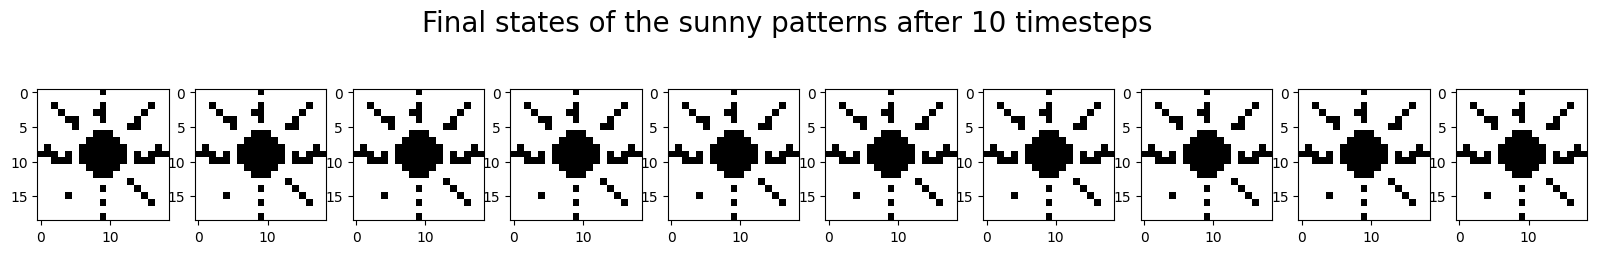

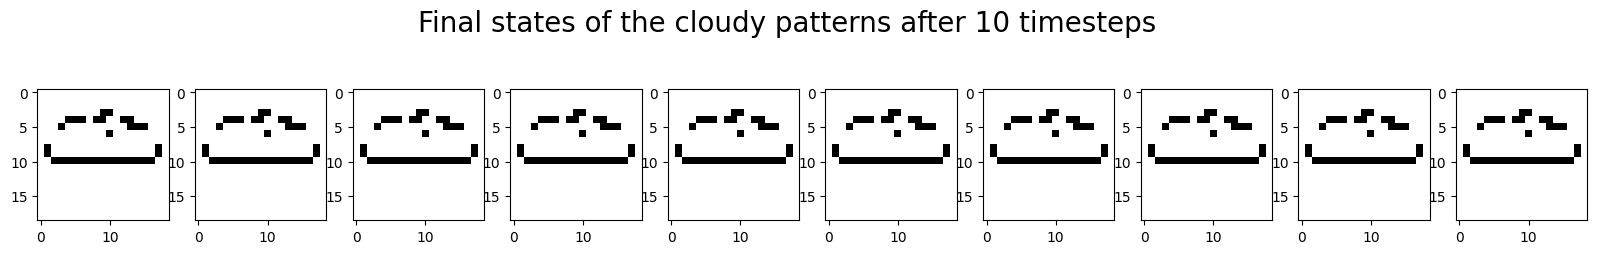

In [10]:
# creating a list with the final states of the patterns
final_sunny_states = [state_evolution_s1[-1], state_evolution_s2[-1], state_evolution_s3[-1], state_evolution_s4[-1], state_evolution_s5[-1],
                      state_evolution_s6[-1], state_evolution_s7[-1], state_evolution_s8[-1], state_evolution_s9[-1], state_evolution_s10[-1]]

final_cloudy_states = [state_evolution_cl1[-1], state_evolution_cl2[-1], state_evolution_cl3[-1], state_evolution_cl4[-1], state_evolution_cl5[-1],
                      state_evolution_cl6[-1], state_evolution_cl7[-1], state_evolution_cl8[-1], state_evolution_cl9[-1], state_evolution_cl10[-1]]

plt.figure(figsize=(20,3))
plt.suptitle('Final states of the sunny patterns after 10 timesteps', fontsize = 20)
index = 1
# Plotting the final states of the sunny patterns
for final_state in final_sunny_states:
  plt.subplot(1, len(final_sunny_states), index)
  plt.imshow(final_state.reshape(19,19), cmap = reversed_map)
  index += 1

plt.figure(figsize=(20,3))
plt.suptitle('Final states of the cloudy patterns after 10 timesteps', fontsize = 20)
index = 1
# Plotting the final states of the cloudy patterns
for final_state in final_cloudy_states:
  plt.subplot(1, len(final_cloudy_states), index)
  plt.imshow(final_state.reshape(19,19), cmap = reversed_map)
  index += 1

#Image Classification; Implementation of a FFNN on Hopfield's retrieved memories

##Dot product as classification algorithm for the sunny patterns

Numerous methods exist to classify patterns. A simple mathematical technique concerns the dot product; an operation that calculates the amount of overlap between two vectors. Thus, by performing the dot product between a chosen "ground truth" (e.g. the first sunny pattern) and the final states, as acquired via the Hopfield network, the comparibility between those patterns is obtained. Using a threshold, the outcome of the dot product can then be categorised into "sufficiently equal to the ground truth" and "too different from the ground truth". E.g. if a sunny pattern is used as ground truth, patterns for which the dot product exceeds the threshold will be classified as sunny patterns.

In [11]:
threshold = 300                                       # Threshold that determines how many neurons are allowed to be in the incorrect state, compared to the activations of the units in the pattern they are compared with

# Create a variable "input" containing all the final states
input = []
for i in range (0,10):
  input.append(final_sunny_states[i])
for i in range (0,10):
  input.append(final_cloudy_states[i])

# Define a function that calculates the dot product between two patterns, and classifies the outcome
def dot_classification(input, ground_truth, threshold):
  output = np.dot(input, ground_truth) >= threshold
  return output

prediction = dot_classification(input, s1_flat, threshold)
prediction = np.where(prediction == True, 'Sun', 'Cloud')
print(prediction.reshape((2,10)))

[['Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud'
  'Cloud']
 ['Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud'
  'Cloud']]


##Single-layer Perceptron

Another method of classificiation regards the perceptron algorithm: a supervised machine learning algorithm of binary classifiers. Unlike classification using the dot product, the single layer perceptron doesn't require specifying a single "ground truth". Instead, all of the patterns in the dataset can be used as training data for the perceptron, after which the error is used to update the weights. The weights are updated according to the perceptron training rule:
$$Δw_i=η(t-o)x_i$$
Where:
* $Δw_i$ is the change of the weight of the $i^{th}$ connection (the connection between node $i$ and the perceptron)
* $η$ is the learning rate
* $t$ is the target value (i.e. the ground truth label)
  * Every pattern in the training dataset is assigned a ground truth label
* $o$ is the output of the perceptron
* $x_i$ is the input value of the $i^{th}$ node in the input layer, given a certain pattern $x$

Thus, by effectuating the perceptron training rule for every pattern in the training dataset, the weights get updated accordingly. This process is repeated for a set number of epochs, after which the final weights are retrieved.  

After the training process is completed, the perceptron algorithm can be implemented for categorization of the final state patterns, using its optimised weight values.

### Training the perceptron algorithm

In [12]:
# Create a variable "training_data" containing the entire training dataset
# Each activation value in a pattern will serve as an input node for the perceptron
training_data = []
for i in range (0,10):
  training_data.append(sunny_patterns_flat[i])
for i in range (0,10):
  training_data.append(cloudy_patterns_flat[i])

training_data = np.array(training_data)                       # Converging the list into an array

target_values = np.array([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
                           0, 0, 0 ,0 ,0, 0, 0, 0, 0, 0]]).T  # The target values of every pattern in the training dataset: Note, 1 represents 'Sun', and 0 represents 'Cloud'

np.random.seed(1)
synaptic_weights = 2 * np.random.rand(19*19,1) - 1            # Generating a random initial weights matrix with a mean of 0 and a variance of 1

def heaviside(x):                                             # Defining the Heaviside step function
  x = np.where(x >= 0, 1, 0)
  return x

epochs = 20
for j in range(0,epochs):                                         # Run through the entire training dataset for # epochs
  for i in range(0, training_data.shape[0]):                      # Update the weights, using a single pattern in the training data a time
    output = heaviside(np.dot(training_data, synaptic_weights)) 	# Perceptron algorithm
    if j == 0 and i == 0:
      print('Categorisation of the initial patterns before training:\n')
      print_output = np.where(output == 1, 'Sun', 'Cloud')
      print(print_output.reshape(2,10))
    error = target_values - output
    weight_change = 0.01*error[i]*training_data[i]                # Perceptron training rule
    synaptic_weights += weight_change.reshape(19*19,1)


print('\n\nCategorisation of the initial patterns after training:\n')
output = np.where(output == 1, 'Sun', 'Cloud')
print(output.reshape(2,10))

Categorisation of the initial patterns before training:

[['Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud'
  'Cloud']
 ['Cloud' 'Cloud' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Cloud' 'Cloud']]


Categorisation of the initial patterns after training:

[['Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun']
 ['Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud'
  'Cloud']]


###Classifying the final states of the patterns

In [13]:
# Create a variable "final_states" containing all the final states of the patterns after 10 iterations through the Hopfield networks
final_states = []
for i in range (0,10):
  final_states.append(final_sunny_states[i])
for i in range (0,10):
  final_states.append(final_cloudy_states[i])

final_states = np.array(final_states)                               # Converging the list into an array

classification =  heaviside(np.dot(final_states, synaptic_weights)) # Perceptron algorithm
classification = np.where(classification == 1, 'Sun', 'Cloud')

print('The perceptron algorithm predicts that the final states of the patterns belong to the following categories: \n')
print(classification.reshape(2,10))


The perceptron algorithm predicts that the final states of the patterns belong to the following categories: 

[['Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun' 'Sun']
 ['Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud' 'Cloud'
  'Cloud']]


#Energy Function of a Hopfield Network

As previously discussed, the Hopfield network converges onto patterns that are stored as fixed point attractors. These fixed point attractors are characterized by the fact that the corresponding Hopfield energy forms a local minimum in the energy landscape. Accordingly, after initialization of the network, it will evolve such that the energy decreases until it reaches a steady state. This phenomenon is described by the following equation:

$$E=-\frac{1}{2}(\sum_{i,j\neq i}{w_{ij} a_i a_j})=-\frac{1}{2}\textbf{a}^T\textbf{Wa}$$

In other words, the Hopfield energy equals (some constant times) the dot product between the current state of the network and the pattern that forms the input to the neurons. Thus, if there is a high overlap (i.e. large dot product) between the synaptic drive (pattern of inputs) and the current state, the Hopfield energy will in return be low. Therefore, the higher the overlap, the lower the Hopfield energy, and the closer the network is to a steady state.




## The always decreasing Hopfield Energy

Considering the energy of only neuron $i$ yields the equation:
$$E=-\frac{1}{2}a_i\sum_{j\neq i}{w_{ij}a_j}$$

If the sign of the neuron equals the sign of the field, the state of the neuron just before responding to the field ($a^-$) matches the state of the neuron just after responding to the field ($a^+$). Therefore the change in the Hopfield energy yields zero:
$$ΔE=E_{new}-E_{old}=-\frac{1}{2}(a_i^+\sum_{j\neq i}{w_{ij}a_j}-a_i^-\sum_{j\neq i}{w_{ij}a_j})=0$$

However, if $a^-$ opposes the sign of the field, the neuron shall flip. Thus: $a^+=-a^-$. This causes the energy to decrease by a minimum increment:
$$ΔE=-\frac{1}{2}(a_i^+\sum_{j\neq i}{w_{ij}a_j}-a_i^-\sum_{j\neq i}{w_{ij}a_j})=-\frac{1}{2}(2a_i^+\sum_{j\neq i}{w_{ij}a_j})=-a_i^+\sum_{j\neq i}{w_{ij}a_j}$$
Because, by definition, the sign of $a^+$ will always be equal to the sign of the field, this increment shall always be negative. Hence, every flip of a neuron guarantees to decrease the energy function.

However, the energy function can never decrease below a certain lower bound:
$$E_{min}=-\frac{1}{2}\sum_{i, j\neq i}{|w_{ij}|}$$

### Energy values of the sunny and cloudy states

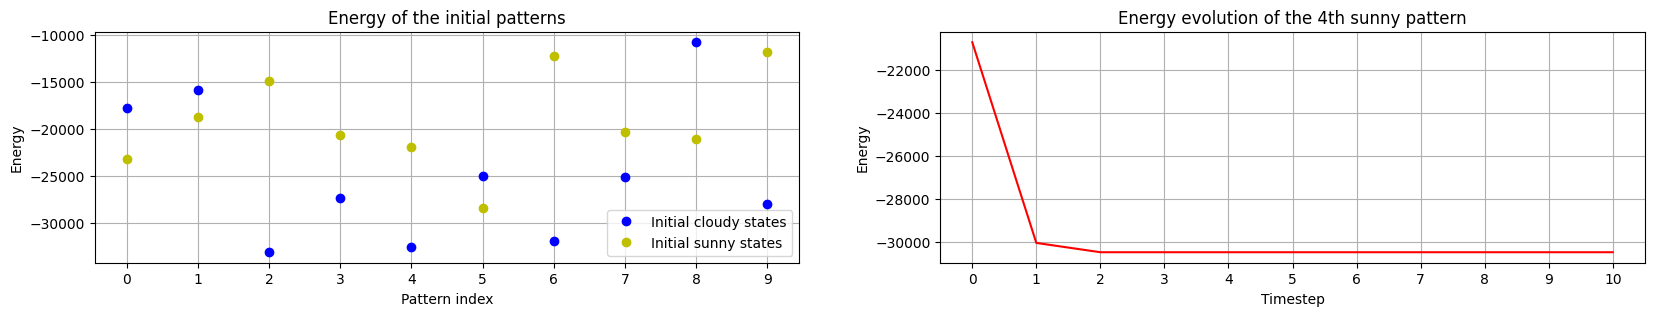

In [14]:
# Defines a function that computes how the Hopfield energy changes for the evolution of a pattern (state)
def hopfield_energy(state_evolution,weights_matrix):
  hopfield_energy = []                        # initiating an empty list, where the different energy values will be appended to
  for state in state_evolution:
    E = -0.5 * (state.T@weights_matrix@state) # computes the hopfield energy for every state
    hopfield_energy.append(E)                 # append the resulting value to the list, to be used for plotting later on
  return hopfield_energy


# Calculate Hopfield Energies
hopfield_energy_4 = hopfield_energy(state_evolution_s4, W)                   # Compute the Hopfield energy for the fourth sunny pattern


# Compute the Hopfield energies of the initial patterns BEFORE they are passed through the Hopfield network
# NOTE: these energies are a function of the weights_matrix, which in turn is a function of the training_set. Therefore, the patterns that the Hopfield network is trained on will be likely to have the lowest energies
hopfield_energy_initial_patterns_cl = hopfield_energy(cloudy_patterns_flat, W)    # plot all the initial energy values of the 10 different cloudy patterns
hopfield_energy_initial_patterns_s = hopfield_energy(sunny_patterns_flat, W)      # plot all the initial energy values of the 10 different sunny patterns

x_axis = range(0,timesteps)                   # Create a x-axis with integers from 0 to the amount of timesteps in the evolution


# Plotting the initial energy of the 10 sunny and 10 cloudy patterns BEFORE they are passed through the Hopfield network
plt.figure(figsize=(20,3))
plt.subplot(1,2,1)
plt.title('Energy of the initial patterns')
plt.plot(x_axis, hopfield_energy_initial_patterns_cl, 'bo', label = 'Initial cloudy states')
plt.plot(x_axis, hopfield_energy_initial_patterns_s, 'yo',label = 'Initial sunny states')
plt.xlabel('Pattern index')
plt.ylabel('Energy')
plt.grid(True)
plt.xticks(x_axis);
plt.legend();

x_axis = range(0,timesteps+1)

# Plotting the energy evolution of the fourth sunny pattern during 10 iterations of the Hopfield network
plt.subplot(1,2,2)
plt.title('Energy evolution of the 4th sunny pattern')
plt.plot(x_axis, hopfield_energy_4, 'r')
plt.xlabel('Timestep')
plt.ylabel('Energy')
plt.grid(True)
plt.xticks(x_axis);

#Capacity of the Hopfield network

The capacity of the original Hopfield network linearly depends on the number of neurons ($N$). Using Hebbian learning, a network of $N$ neurons can store up to ~$0.14N$ **random** patterns with a small retrieval error ($< 0.004$). This can be elucidated as follows:

As proposed before, adequate storage of patterns requires the patterns to be stationary (and stable). A pattern $\xi_p$ is stationary if it satisfies:
$$\xi_i^p\sum_{j\neq i}{w_{ij}\xi_j^p} > 0 \text{ } \forall \text{ } i $$
$$\xi_i^p\frac{1}{N}\sum_{j\neq i}\sum_k{\xi_i^k\xi_j^k\xi_j^p} > 0 \text{ } \forall \text{ } i $$
$$\xi_i^p\frac{1}{N}\sum_{j\neq i}{\xi_i^p\xi_j^p\xi_j^p} + \xi_i^p\frac{1}{N}\sum_{j\neq i}\sum_{k\neq p}{\xi_i^k\xi_j^k\xi_j^p} > 0 \text{ } \forall \text{ } i $$

Note: the first term (left term) equals $1$ because $\xi_i^p\xi_i^p=\xi_j^p\xi_j^p=1$. Thus, the stationarity of the pattern $\xi_p$ depends on the *crosstalk term* $C_i^p$ (the right term):
$$C_i^p := \xi_i^p\frac{1}{N}\sum_{j\neq i}\sum_{k\neq p}{\xi_i^k\xi_j^k\xi_j^p} > -1 \text{ } \forall \text{ } i $$
Therefore, the pattern will not be stored if:
$$C_i^p < -1 \text{ for any } i $$

For purely random $\xi^k$ (meaning that $\xi_i^k \in \{-1,+1\}$ with a variance of $1$), in combination with large $N$ and $k$, the distribution of $C_i^p$ approaches the Gaussian distribution ($\mu = 0, \sigma^2 = K/N$). According to this Gaussian distribution, the propability $P(C_i^p< -1 | \mu=0, \sigma^2=K/N) < 0.004 \text{ for } \frac{K}{N} < 0.14$, corresponding to the the storage capacity stated above.


## Orthogonal patterns

The crosstalk term includes the dot product between $\xi_k$ and $\xi_p$. In other words, it includes the overlap between the pattern $p$, that is to be stored, and all the other patterns $k$. If pattern $p$ is orthogonal to all other patterns, this term will become 0, and thus $C_p=0$. This assures that the stored pattern is stationary, and therefore will be adequately stored. Thus, if all memories are orthogonal to one another, they will all be stable fixed point attractors.

However, memories don't necessarily need to be orthogonal to be valid stable points. Nevertheless, as the correlation between patterns increases, the network becomes more likely to fail in storing them.

##Emergence of spurious states

Upon exceeding the memory capacity, or by storing highly correlated patterns, spurious attractors can emerge.

The first type of spurious patterns are some average of the stored patterns. This is due to the fact that a linear combination of an odd number of stored patterns is also stable:
$$\xi_i^{spurious}=\pm sgn(\pm\xi_i^{p_1} \pm\xi_i^{p_2} \pm\xi_i^{p_3})$$

Furthermore, upon storing a certain pattern $ξ$, the network also stores the opposite pattern $-\xi$. This is due to the symmetry of the energy function. After all, $E$ is a function of $\xi_i \xi_j$ (through the weight matrix) and thus $E(\xi)=E(-\xi)$.

Lastly, local minima can also emerge which are not some linear combination of the stored patterns.  



###Optimization procedure

A possible solution for the emergence of spurious states regards implementing an optimization procedure for the weights, using gradient descent. Optimization aims to minimise the energy for the stored target patterns, while maximising the energy for other patterns. A possible method of calculation regards:

$$\textbf{W}=\textbf{W}+η(∑_{\textbf{a}∈\textbf{ξ}_p}\textbf{aa}^T-∑_{\textbf{a}∉\textbf{ξ}_p}\textbf{aa}^T)$$

The goal of this equation is to minimize the energy at target patterns, while maximising the energy of *all* non-target patterns. However, it might not be necessary to maximise the energy at all the other patterns. Instead, one could only increase the energy of energy minima (valleys) other than those of the target patterns. Furthermore, stochastic gradient descent could be used to merely raise the neighbourhood of target patterns, increasing their stability.

# A glimpse into the future: Modern Hopfield networks

Regardless of its already impressive abilities, the standard Hopfield network is only the beginning. Generalizations of this algorithm have been developed, which succesfully overcome the main limitations of the standard Hopfield network. For example, boltzmann machines allow the network to escape spurious minima by replacing the deterministic nature of the Hopfield network by stochasticity. Furthermore, Modern binary Hopfield networks can have a storage capacity that is exponential in the number of neurons, while being able to converge after a mere single update. Additionaly, the emergence of continuous Hopfield networks also enables differentiability for gradient descent, and thus can be used within deep neural networks.

#Resources


* Anas Brital | Perceptron Algorithm Explained . (n.d.). Retrieved October 28, 2022, from https://anasbrital98.github.io/blog/2021/Perceptron/
* Carnegie Mellon University Deep Learning. (2021, December 25). Lecture 25: Hopfield Nets and Auto Associators. YouTube. https://www.youtube.com/watch?v=02sKgx5-UAE
* Crouse, E. (2022, May 18). Hopfield Networks: Neural Memory Machines. Towards Data Science. https://towardsdatascience.com/hopfield-networks-neural-memory-machines-4c94be821073
* Discrete Hopfield Network — NeuPy. (2015, September 20). http://neupy.com/2015/09/20/discrete_hopfield_network.html
* Folli, V., Leonetti, M., & Ruocco, G. (2017). On the Maximum Storage Capacity of the Hopfield Model. Frontiers in Computational Neuroscience, 10. https://doi.org/10.3389/fncom.2016.00144
* Hopfield, J. J. (2007, May 11). Hopfield network - Scholarpedia. http://www.scholarpedia.org/article/Hopfield_network
* Hubert Ramsauer, Bernhard Schäfl, Johannes M. Lehner, Philipp Seidl, Michael Widrich, Thomas Adler, Lukas Gruber, Markus Holzleitner, Milena Pavlović, Geir Kjetil Sandve, Victor Greiff, David P. Kreil, Michael K Kopp, Günter Klambauer, Johannes Brandstetter, & Sepp Hochreiter. (2020). Hopfield Networks is All You Need. ArXiv: Neural and Evolutionary Computing. http://arxiv.org/pdf/2008.02217.pdf
* MDLawn. (2019, October 5). The Perceptron Training Rule. ML-DAWN. https://www.mldawn.com/the-perceptron-training-rule/
* MIT OpenCourseWare. (2020, June 29). 20: Hopfield Networks - Intro to Neural Computation. YouTube. https://www.youtube.com/watch?v=gt52wUN3VrQ
* Yannic Kilcher. (2020, August 9). Hopfield Networks is All You Need (Paper Explained). YouTube. https://www.youtube.com/watch?v=nv6oFDp6rNQ
